Reference: 
https://www.kaggle.com/ryanholbrook/principal-component-analysis#kln-21

https://www.geeksforgeeks.org/implementing-pca-in-python-with-scikit-learn/#:~:text=%20Python%20Implementation%3A%20%201%20To%20implement%20PCA,the%20variance%20explained%20by%20each%20principal...%20More%20

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_selection import mutual_info_regression

from xgboost.sklearn import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import recall_score, f1_score, precision_score, precision_recall_fscore_support
from sklearn.metrics import accuracy_score

import seaborn as sns

In [18]:
# 110 cols of 267 cols
x_cols = [ 'bid',  'bid_size', 'ask',  'ask_size', 'last', 'last_size', 'hist_volatility',  'implied_volatility', 
'n5s',  'n15s', 'n30s', 'n60s', 'n300s',    'n600s', 
'n5s_delta',    'n15s_delta',   'n30s_delta',   'n60s_delta',   'n300s_delta',  'n600s_delta',
'c_w1_n3_ask',  'c_w1_n3_bid',  'c_w1_n3_last', 'c_w1_n3_time_value',   'c_w1_n3_theta',    'c_w1_n3_implied_volatility',               
'c_w1_n2_ask',  'c_w1_n2_bid',  'c_w1_n2_last', 'c_w1_n2_time_value',   'c_w1_n2_theta',    'c_w1_n2_implied_volatility',               
'c_w1_n1_ask',  'c_w1_n1_bid',  'c_w1_n1_last', 'c_w1_n1_time_value',   'c_w1_n1_theta',    'c_w1_n1_implied_volatility',               
'c_w1_p1_ask',  'c_w1_p1_bid',  'c_w1_p1_last', 'c_w1_p1_time_value',   'c_w1_p1_theta',    'c_w1_p1_implied_volatility',               
'c_w1_p2_ask',  'c_w1_p2_bid',  'c_w1_p2_last', 'c_w1_p2_time_value',   'c_w1_p2_theta',    'c_w1_p2_implied_volatility',               
'c_w1_p3_ask',  'c_w1_p3_bid',  'c_w1_p3_last', 'c_w1_p3_time_value',   'c_w1_p3_theta',    'c_w1_p3_implied_volatility',               
'c_w2_n3_ask',  'c_w2_n3_bid',  'c_w2_n3_last', 'c_w2_n3_time_value',   'c_w2_n3_theta',    'c_w2_n3_implied_volatility',               
'c_w2_n2_ask',  'c_w2_n2_bid',  'c_w2_n2_last', 'c_w2_n2_time_value',   'c_w2_n2_theta',    'c_w2_n2_implied_volatility',               
'c_w2_n1_ask',  'c_w2_n1_bid',  'c_w2_n1_last', 'c_w2_n1_time_value',   'c_w2_n1_theta',    'c_w2_n1_implied_volatility',               
'c_w2_p1_ask',  'c_w2_p1_bid',  'c_w2_p1_last', 'c_w2_p1_time_value',   'c_w2_p1_theta',    'c_w2_p1_implied_volatility',               
'c_w2_p2_ask',  'c_w2_p2_bid',  'c_w2_p2_last', 'c_w2_p2_time_value',   'c_w2_p2_theta',    'c_w2_p2_implied_volatility',               
'c_w2_p3_ask',  'c_w2_p3_bid',  'c_w2_p3_last', 'c_w2_p3_time_value',   'c_w2_p3_theta',    'c_w2_p3_implied_volatility',               
'c_w3_n3_ask',  'c_w3_n3_bid',  'c_w3_n3_last', 'c_w3_n3_time_value',   'c_w3_n3_theta',    'c_w3_n3_implied_volatility',               
'c_w3_n2_ask',  'c_w3_n2_bid',  'c_w3_n2_last', 'c_w3_n2_time_value',   'c_w3_n2_theta',    'c_w3_n2_implied_volatility',               
'c_w3_n1_ask',  'c_w3_n1_bid',  'c_w3_n1_last', 'c_w3_n1_time_value',   'c_w3_n1_theta',    'c_w3_n1_implied_volatility',               
'c_w3_p1_ask',  'c_w3_p1_bid',  'c_w3_p1_last', 'c_w3_p1_time_value',   'c_w3_p1_theta',    'c_w3_p1_implied_volatility',               
'c_w3_p2_ask',  'c_w3_p2_bid',  'c_w3_p2_last', 'c_w3_p2_time_value',   'c_w3_p2_theta',    'c_w3_p2_implied_volatility',               
'c_w3_p3_ask',  'c_w3_p3_bid',  'c_w3_p3_last', 'c_w3_p3_time_value',   'c_w3_p3_theta',    'c_w3_p3_implied_volatility'
]

#x_cols = ['volume', 'c_w1_p3_theta','c_w1_p2_theta','c_w3_n2_theta','c_w2_p3_theta','c_w3_p1_theta','c_w2_n1_theta','c_w3_n1_theta','c_w3_n3_theta','c_w2_n2_theta','c_w2_p1_theta','c_w2_p2_theta','c_w1_n1_theta','c_w1_p1_theta','c_w3_p3_theta','c_w2_n3_theta','c_w3_p2_theta', 'c_w1_n2_theta','c_w1_n3_theta','implied_volatility','hist_volatility']
y_cols = ['p30s_bucket']  # ,  'p5s_bucket', 'p30s_bucket', 'p60s_bucket']
bin_counts = 5

file_list = ['ml_cp18/ml_cp18_AAPL20220103.csv','ml_cp18/ml_cp18_AAPL20220104.csv', 'ml_cp18/ml_cp18_AAPL20220105.csv', 'ml_cp18/ml_cp18_AAPL20220106.csv', 'ml_cp18/ml_cp18_AAPL20220107.csv',]
file_list_train = file_list[:-1]
file_list_test = file_list[-1:]


# PCA Analysis of all columns and all files

## Load All Data

In [19]:
import os
data = None
for file in file_list:
    file = "../" + file
    assert os.path.exists(file), "Data file does not exist!"
    data_tmp = pd.read_csv(file, low_memory=False)
    if data is None:
        data = data_tmp
    else:
        data = data.append(data_tmp, ignore_index=True)
print ('loaded data', data.shape)
data = data.dropna()
print ('after dropna', data.shape)

loaded data (69316, 267)
after dropna (46789, 267)


## Scale Data

In [20]:
# Get the numeric cols to scale
subset = x_cols + y_cols
data = data [ subset ]

numeric_cols = [] 
for i, v in data.dtypes.items():
    # print(f'index: {i} and value: {v}')
    if v != 'object': numeric_cols.append(i)
#print(numeric_cols)
data_numbers = data [ numeric_cols ]
data_target = data [ y_cols ]
print(data_numbers.shape)
x_cols_numeric = data_numbers.columns
print (x_cols_numeric)

(46789, 129)
Index(['bid', 'bid_size', 'ask', 'ask_size', 'last', 'last_size',
       'hist_volatility', 'implied_volatility', 'n5s', 'n15s',
       ...
       'c_w3_p2_time_value', 'c_w3_p2_theta', 'c_w3_p2_implied_volatility',
       'c_w3_p3_ask', 'c_w3_p3_bid', 'c_w3_p3_last', 'c_w3_p3_time_value',
       'c_w3_p3_theta', 'c_w3_p3_implied_volatility', 'p30s_bucket'],
      dtype='object', length=129)


In [21]:
scalar = StandardScaler()
scalar.fit(data_numbers)
data_scaled = scalar.transform(data_numbers)

## Perform PCA Analysis

In [40]:
#from sklearn.decomposition import PCA
#pca = PCA(n_components=4).fit(data_scaled)
#pca_transformed = pca.transform(data_scaled)

#plt.plot(np.cumsum(pca.explained_variance_ratio_))
#plt.xlim(0,7,1)
#plt.xlabel('Number of components')
#plt.ylabel('Cumulative explained variance')

from sklearn.decomposition import KernelPCA
kernel_pca = KernelPCA(n_components = 3, kernel ="rbf", gamma = 0.03)
# fit and transform the data
final = kernel_pca.fit_transform(data_scaled)
 
# prints an 2d-array (as n_components = 2)
print(final)

#plt.plot(np.cumsum(kernel_pca.explained_variance_ratio_))
#plt.xlim(0,7,1)
#plt.xlabel('Number of components')
#plt.ylabel('Cumulative explained variance')


[[0.0047 0.1603 0.1557]
 [0.0047 0.1599 0.1551]
 [0.0042 0.1304 0.0709]
 ...
 [0.0036 0.1121 0.0228]
 [0.0036 0.1121 0.0228]
 [0.0036 0.1121 0.0228]]


AttributeError: 'KernelPCA' object has no attribute 'explained_variance_ratio_'

In [41]:
print(final)

[[0.0047 0.1603 0.1557]
 [0.0047 0.1599 0.1551]
 [0.0042 0.1304 0.0709]
 ...
 [0.0036 0.1121 0.0228]
 [0.0036 0.1121 0.0228]
 [0.0036 0.1121 0.0228]]


In [27]:
np.set_printoptions(suppress=True, precision=4)
print(pca.explained_variance_ratio_)
np.set_printoptions()  # reset print options

[0.4907 0.2426 0.1339 0.0275]


In [28]:
plot_variance(pca)

NameError: name 'plot_variance' is not defined

In [29]:
pca_transformed

array([[ 2.2443, 12.2749,  3.1015, -3.0819],
       [ 2.1988, 12.3861,  2.918 , -2.7419],
       [ 1.4515, 11.8672,  3.5212, -4.3544],
       ...,
       [15.9753, -3.7914,  9.1115, 13.2764],
       [15.4163, -5.9506, 11.6873, 11.5393],
       [15.2522, -6.9219, 12.9845, 11.4196]])

In [30]:
pca.explained_variance_ratio_

array([0.4907, 0.2426, 0.1339, 0.0275])

### Graphing all target columns (p0 - p4)

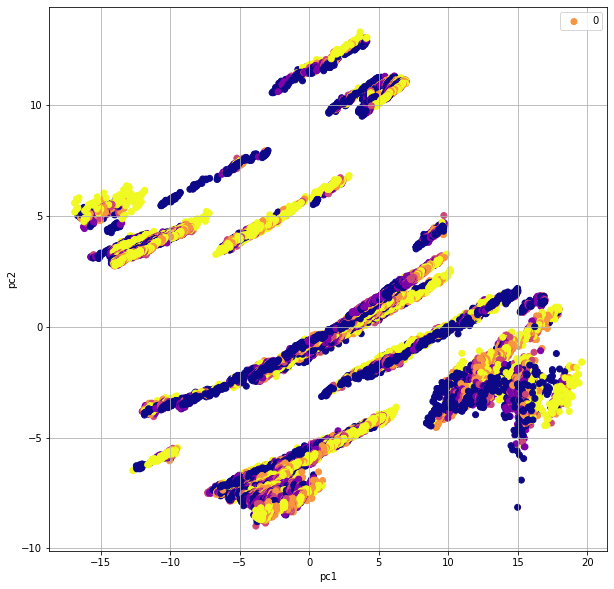

In [31]:
plt.figure(figsize=(10,10))
plt.scatter(pca_transformed[:,0],pca_transformed[:,1],c=(data_target.astype('int')).iloc[:, 0],cmap='plasma')
plt.xlabel('pc1')
plt.ylabel('pc2')

plt.legend(['0', '1', '2', '3', '4', '5'])
plt.grid(True)
plt.show()

Text(0.5, 0, 'PC3')

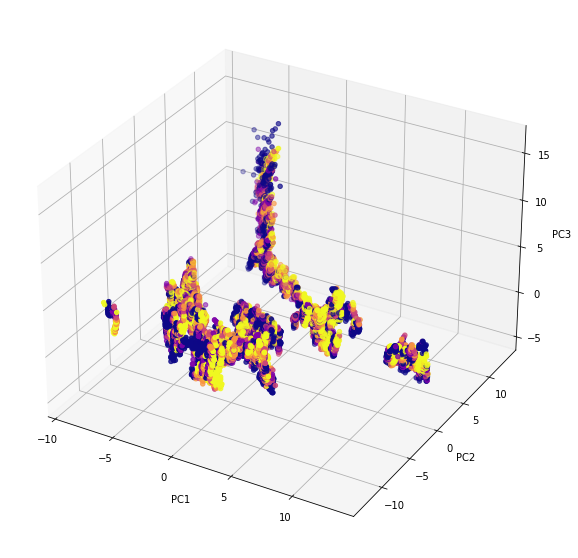

In [39]:
# import relevant libraries for 3d graph
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,10))

# choose projection 3d for creating a 3d graph
axis = fig.add_subplot(111, projection='3d')
# x[:,0]is pc1,x[:,1] is pc2 while x[:,2] is pc3

axis.scatter(kernel_pca[:,1],kernel_pca[:,2],kernel_pca[:,3],c=(data_target.astype('int')).iloc[:, 0],cmap='plasma')
#axis.scatter(pca_transformed[:,1],pca_transformed[:,2],pca_transformed[:,3],c=(data_target.astype('int')).iloc[:, 0],cmap='plasma')
#axis.scatter(x[:,0],x[:,1],x[:,2], c=data['target'],cmap='plasma')
axis.set_xlabel("PC1", fontsize=10)
axis.set_ylabel("PC2", fontsize=10)
axis.set_zlabel("PC3", fontsize=10)


Text(0.5, 0, 'PC3')

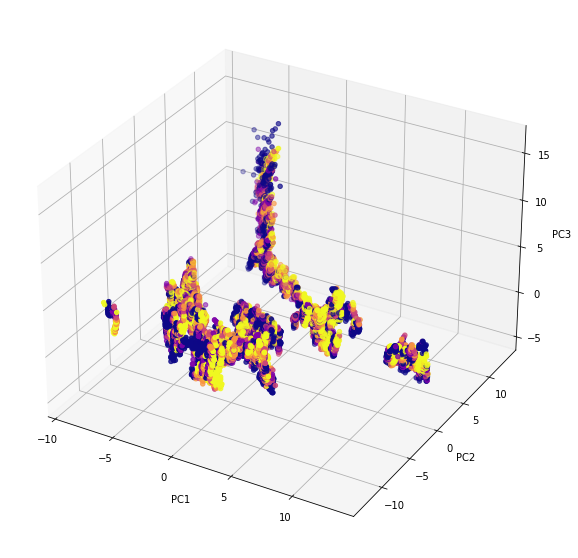

In [33]:
# import relevant libraries for 3d graph
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,10))

# choose projection 3d for creating a 3d graph
axis = fig.add_subplot(111, projection='3d')
# x[:,0]is pc1,x[:,1] is pc2 while x[:,2] is pc3
axis.scatter(pca_transformed[:,1],pca_transformed[:,2],pca_transformed[:,3],c=(data_target.astype('int')).iloc[:, 0],cmap='plasma')
#axis.scatter(x[:,0],x[:,1],x[:,2], c=data['target'],cmap='plasma')
axis.set_xlabel("PC1", fontsize=10)
axis.set_ylabel("PC2", fontsize=10)
axis.set_zlabel("PC3", fontsize=10)


Text(0.5, 0, 'PC3')

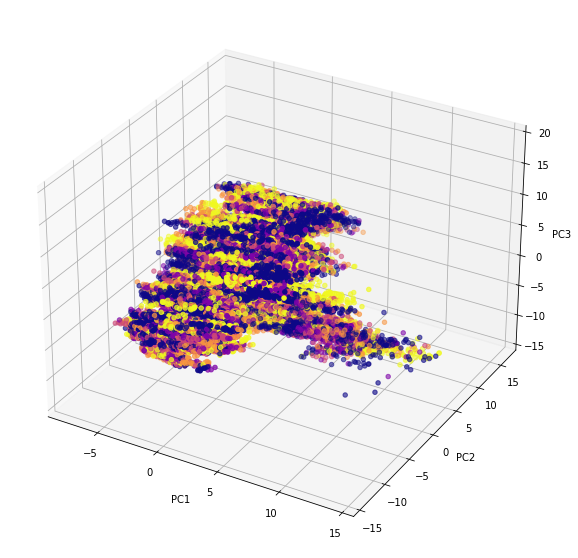

In [16]:
# import relevant libraries for 3d graph
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,10))

# choose projection 3d for creating a 3d graph
axis = fig.add_subplot(111, projection='3d')
# x[:,0]is pc1,x[:,1] is pc2 while x[:,2] is pc3
axis.scatter(pca_transformed[:,3],pca_transformed[:,1],pca_transformed[:,2],c=(data_target.astype('int')).iloc[:, 0],cmap='plasma')
#axis.scatter(x[:,0],x[:,1],x[:,2], c=data['target'],cmap='plasma')
axis.set_xlabel("PC1", fontsize=10)
axis.set_ylabel("PC2", fontsize=10)
axis.set_zlabel("PC3", fontsize=10)


### Graphing each target class

Text(0.5, 0, 'PC3')

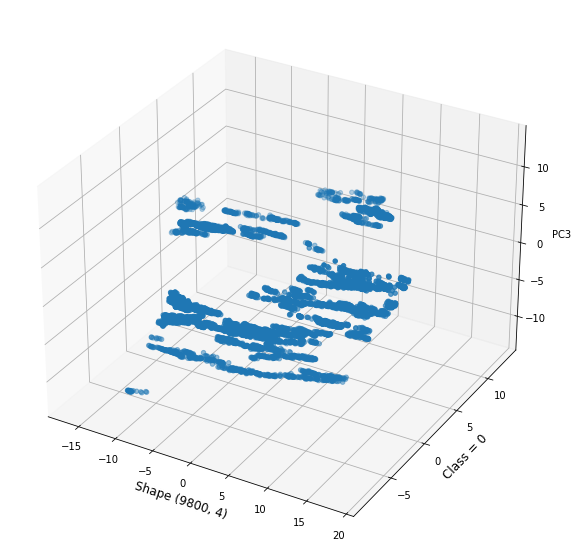

In [34]:
target_class = 0
fig = plt.figure(figsize=(10,10))
# choose projection 3d for creating a 3d graph
axis = fig.add_subplot(111, projection='3d')
# x[:,0]is pc1,x[:,1] is pc2 while x[:,2] is pc3
one_class = pca_transformed[ data [ 'p30s_bucket' ] == target_class ] 
axis.scatter(one_class[:,0],one_class[:,1],one_class[:,2],cmap='plasma')
#axis.scatter(x[:,0],x[:,1],x[:,2], c=data['target'],cmap='plasma')
axis.set_xlabel("Shape " + str(one_class.shape), fontsize=12)
axis.set_ylabel("Class = " + str(target_class) , fontsize=12)
axis.set_zlabel("PC3", fontsize=10)


Text(0.5, 0, 'PC3')

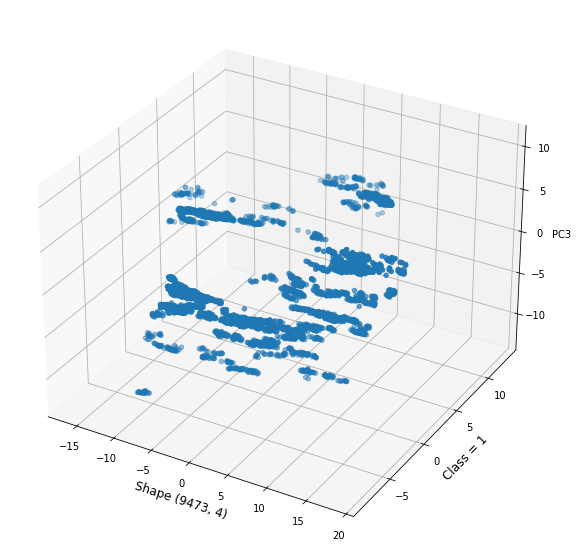

In [35]:
target_class = 1
fig = plt.figure(figsize=(10,10))
# choose projection 3d for creating a 3d graph
axis = fig.add_subplot(111, projection='3d')
# x[:,0]is pc1,x[:,1] is pc2 while x[:,2] is pc3
one_class = pca_transformed[ data [ 'p30s_bucket' ] == target_class ] 
axis.scatter(one_class[:,0],one_class[:,1],one_class[:,2],cmap='plasma')
#axis.scatter(x[:,0],x[:,1],x[:,2], c=data['target'],cmap='plasma')
axis.set_xlabel("Shape " + str(one_class.shape), fontsize=12)
axis.set_ylabel("Class = " + str(target_class) , fontsize=12)
axis.set_zlabel("PC3", fontsize=10)



Text(0.5, 0, 'PC3')

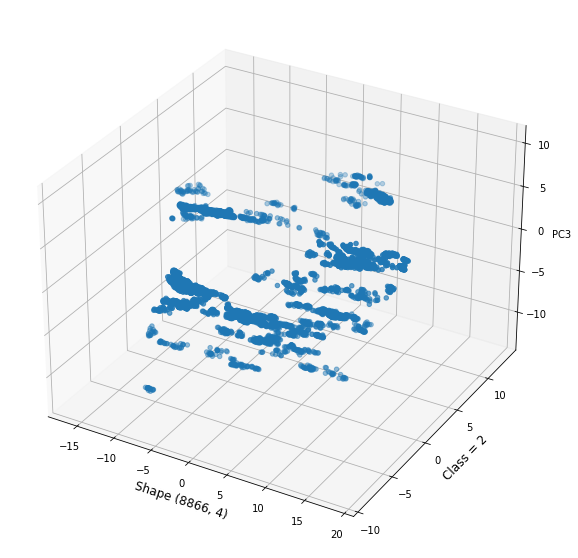

In [36]:
target_class = 2
fig = plt.figure(figsize=(10,10))
# choose projection 3d for creating a 3d graph
axis = fig.add_subplot(111, projection='3d')
# x[:,0]is pc1,x[:,1] is pc2 while x[:,2] is pc3
one_class = pca_transformed[ data [ 'p30s_bucket' ] == target_class ] 
axis.scatter(one_class[:,0],one_class[:,1],one_class[:,2],cmap='plasma')
#axis.scatter(x[:,0],x[:,1],x[:,2], c=data['target'],cmap='plasma')
axis.set_xlabel("Shape " + str(one_class.shape), fontsize=12)
axis.set_ylabel("Class = " + str(target_class) , fontsize=12)
axis.set_zlabel("PC3", fontsize=10)



Text(0.5, 0, 'PC3')

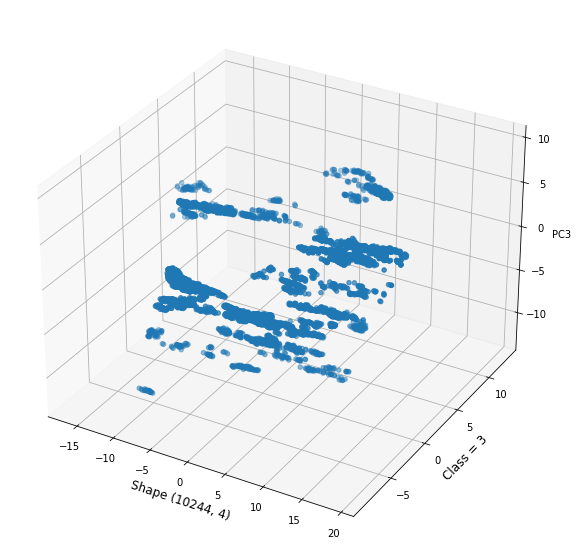

In [37]:
target_class = 3
fig = plt.figure(figsize=(10,10))
# choose projection 3d for creating a 3d graph
axis = fig.add_subplot(111, projection='3d')
# x[:,0]is pc1,x[:,1] is pc2 while x[:,2] is pc3
one_class = pca_transformed[ data [ 'p30s_bucket' ] == target_class ] 
axis.scatter(one_class[:,0],one_class[:,1],one_class[:,2],cmap='plasma')
#axis.scatter(x[:,0],x[:,1],x[:,2], c=data['target'],cmap='plasma')
axis.set_xlabel("Shape " + str(one_class.shape), fontsize=12)
axis.set_ylabel("Class = " + str(target_class) , fontsize=12)
axis.set_zlabel("PC3", fontsize=10)



Text(0.5, 0, 'PC3')

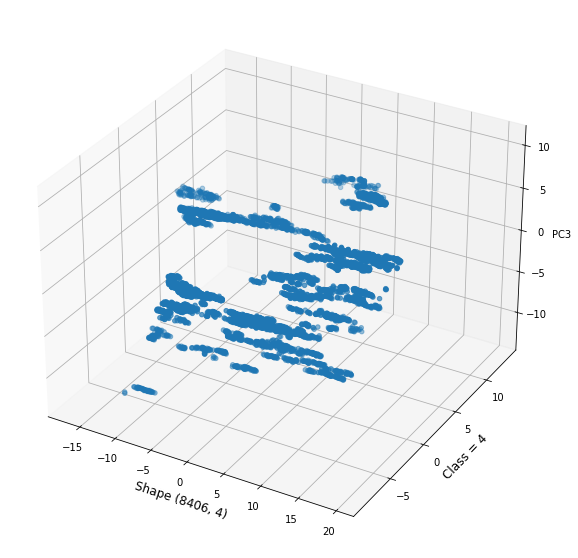

In [38]:
target_class = 4
fig = plt.figure(figsize=(10,10))
# choose projection 3d for creating a 3d graph
axis = fig.add_subplot(111, projection='3d')
# x[:,0]is pc1,x[:,1] is pc2 while x[:,2] is pc3
one_class = pca_transformed[ data [ 'p30s_bucket' ] == target_class ] 
axis.scatter(one_class[:,0],one_class[:,1],one_class[:,2],cmap='plasma')
#axis.scatter(x[:,0],x[:,1],x[:,2], c=data['target'],cmap='plasma')
axis.set_xlabel("Shape " + str(one_class.shape), fontsize=12)
axis.set_ylabel("Class = " + str(target_class) , fontsize=12)
axis.set_zlabel("PC3", fontsize=10)

